In [4]:
%load_ext ipympl
%matplotlib widget

import numpy as np
import importlib, game_3dutils, game_costs,neos_path_game, ukf_estimator,game_viz, game_runner_diff #game_runner_mcp,  rl_infer
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

import torch

importlib.reload(game_3dutils)
importlib.reload(game_costs)
importlib.reload(neos_path_game)
importlib.reload(ukf_estimator)
importlib.reload(game_viz)
# importlib.reload(rl_infer)
importlib.reload(game_runner_diff)
# importlib.reload(game_runner_mcp)


from game_3dutils    import run_rhc_and_collect_frames_3d, run_rhc_with_rl_and_collect_frames_3d
from game_runner_diff import run_rhc_with_rl_and_collect_frames_3d_diff
from game_costs import build_game_costs
from game_viz import animate_rollout_3d, interactive_rollout_3d


from dyn_models import (
    hcw_mean_motion, hcw_discrete_mats, as_numpy_const, dims_from_D,
    augment_AB_for_att, augment_bounds_with_att, pad_x0_with_att,
    frame_from_axis_continuous, world_to_body_R, apply_roll_about_axis
)



The ipympl module is not an IPython extension.


DEF ckpt? True ATT ckpt? False | attacker_mode: rule
600
[rl_infer_diff] DEF load: missing: ['layer.Ad', 'layer.Bd', 'layer.P']  unexpected: []
Saved 3D animation to traj_3D_rl.gif


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 600) to (704, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved animation to traj_3D_rl.mp4


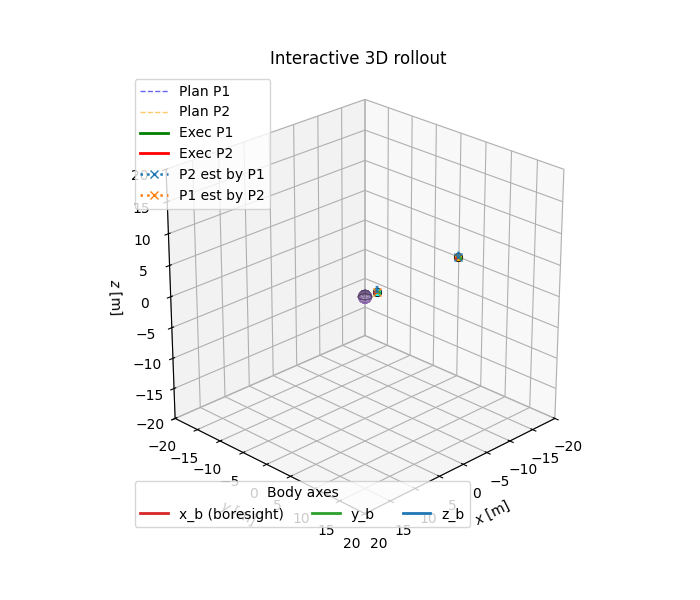

In [ ]:
# if __name__ == "__main__":

#     # 2) Generate rollout DATA
#     # rollout = run_rhc_and_collect_frames_3d(cfg=CONFIG)
#     rollout = run_rhc_with_rl_and_collect_frames_3d(cfg=CONFIG)

#     # 3) Make a GIF or MP4 directly from the rollout (pick one)
#     # GIF:
#     animate_rollout_3d(rollout, save_path="traj_3D.gif", fps=20, cfg=CONFIG, show_fov=True, show_axes=True);

#     import imageio.v3 as iio
#     gif_frames = iio.imread("traj_3D.gif")
#     iio.imwrite("traj_3D.mp4", gif_frames, fps=20, codec="h264")
#     print("Saved animation to traj_3D.mp4")

#     # 4) INTERACTIVE viewer (Jupyter/Colab)
#     interactive_rollout_3d(rollout, CONFIG, show_fov=True, show_axes=True)
#     plt.show()  # ensure it displays


# CONFIG_RL = {
#     "seed": 42,
#     "device": "cpu",            # "cuda" if available

#     # --- dynamics ---
#     "D": 3,
#     "dt": 0.1,
#     "T": 45,                    # control steps per episode (per-env horizon)
#     "dynamics": "hcw",
#     "hcw": {"mu": 3.986004418e14, "r0": 6_371_000.0 + 400_000.0},
#     "use_att": False,

#     # arena (centered)
#     "arena": {"type": "sphere", "cx": 0.0, "cy": 0.0, "cz": 0.0, "r": 10.0},
#     "arena_terminate_margin": 1.0,  # terminate if ||p|| >= margin * radius

#     # action bound (per-axis clip ±umax) — LVLH acceleration [m/s^2]
#     "umax": 1.0,

#     # initial states: shape (2, 2*D) as [px,py,pz, vx,vy,vz] per agent
#     "x0": np.array([
#         [ -2.5,  0.0, 0.0,  -0.02, 0.00,  0.000],  # defender
#         [-5, 0.0, 0.0,   0.00, 0.00, -1.000],  # attacker
#     ], dtype=float),
#     "x0_jitter": {"pos": 0.5, "vel": 0.01},

#     # PPO rollout settings (fixed length batches)
#     "num_envs": 8,
#     "steps_per_env": 256,       # total batch = 8 * 256 = 2048 transitions / update
#     "total_updates": 300,       # number of PPO updates (roughly ≈ episodes/(T))

#     # PPO hyperparams
#     "gamma": 0.97,
#     "gae_lambda": 0.95,
#     "clip_eps": 0.2,
#     "policy_lr": 3e-4,
#     "value_lr": 1e-3,
#     "train_epochs": 10,
#     "minibatch_size": 1024,
#     "entropy_coef": 0.02,
#     "value_coef": 0.5,
#     "max_grad_norm": 1.0,
#     "log_every": 10,

#     # dynamics matrices are filled in __main__
#     "dyn": {"Ad": None, "Bd": None},

#     # shaping knobs (normalized distance)
#     "dense_coef": 0.03,         # α: weight on (d2_next - d2_prev)
#     "term_coef": 1.0,           # β: terminal ± d_T^2
#     "step_pos_coef": 0.01,      # +k d^2 for def, -k d^2 for att
#     "step_vel_coef": 0.0005,    # penalize speed
#     "effort_def": 0.01,         # λ_D: per-step ||a_def||^2
#     "effort_att": 0.01,         # λ_A: per-step ||a_att||^2
#     "wall_penalty": 2.0,        # soft wall pressure / OOB bonus

#     # Rollout-specific toggles
#     "infer_obs_variant": "train",   # try: "train", "swap12", "rel21", "velswap"
#     "obsnorm": False,               # keep False unless you trained with it and saved stats
#     "ckpt_def": "ppo_def.pt",
#     "ckpt_att": "ppo_att.pt",
#     "debug_actions": True,          # prints first ~5 steps of norms, saturation, and d^2 trend

# }


if __name__ == "__main__":
    import os
    from pathlib import Path
    import shutil
    import imageio.v3 as iio
    import numpy as np

    # Your HCW helpers (if needed elsewhere in main)
    from dyn_models import hcw_mean_motion, hcw_discrete_mats, as_numpy_const

    # Pull a rollout config from the single source of truth
    import config_rl
    importlib.reload(config_rl)
    from config_rl import config_for_eval, build_dyn

    CKPT_DIR = Path("Training_Policy")
    POLICY = "ppo_def_ukf_distilled.pt"
    # POLICY = "ppo_def.pt"


    # POLICY = "ppo_def.pt"


    # If you trained with the rule-based attacker (default), keep attacker_mode="rule".
    # If you trained an RL attacker too, set attacker_mode="rl".
    cfg = config_for_eval(
        attacker_mode="rule",        # or "rl"
        umax=2,                 # override if your ckpt used a different bound
        T=600,                     # override horizon if you want
    )

    cfg["x0"] = np.array([
        [  2.5, 0.0, 0.0,  -0.02, 0.00, 0.000],  # defender
        [ -19.9, 0.0, 0.0,  +0.02, 0.00, 0.000], # attacker
    ], dtype=float)

    cfg["use_ukf"] = True

    # Fill Ad/Bd (float32) from HCW
    build_dyn(cfg)

    # Point to checkpoints inside Training_Policy
    cfg["ckpt_def"] = str(CKPT_DIR / POLICY)
    if cfg.get("attacker_mode", "rule") == "rl":
        cfg["ckpt_att"] = str(CKPT_DIR / "ppo_att.pt")

    print(
        "DEF ckpt?", os.path.exists(cfg["ckpt_def"]),
        "ATT ckpt?", os.path.exists(cfg.get("ckpt_att", "")),
        "| attacker_mode:", cfg.get("attacker_mode")
    )

    # ---- Run rollout (pick the runner you actually use) ----
    # Prefer cfg["T"] so horizon stays consistent with config
    steps = int(cfg["T"])
    steps = int(600)
    print(steps)
    # raise("Debug")

    # Example runners – uncomment the one you actually have:
    # rollout = run_rhc_with_rl_and_collect_frames_3d(cfg, steps=steps, turn_len=1)
    rollout = run_rhc_with_rl_and_collect_frames_3d_diff(cfg, steps=steps)
    # rollout = run_rhc_with_rl_and_collect_frames_3d_mcp(cfg, steps=steps)

    # ---- Animate & save ----
    animate_rollout_3d(
        rollout,
        save_path="traj_3D_rl.gif",
        fps=20,
        cfg=cfg,
        show_fov=True,
        show_axes=True,
    )
    gif_frames = iio.imread("traj_3D_rl.gif")
    iio.imwrite("traj_3D_rl.mp4", gif_frames, fps=20, codec="h264")
    print("Saved animation to traj_3D_rl.mp4")

    # Optional interactive viewer
    interactive_rollout_3d(rollout, cfg, show_fov=True, show_axes=True)

    # ---- Cleanup local __pycache__ safely (optional) ----
    for p in Path('.').rglob('__pycache__'):
        shutil.rmtree(p, ignore_errors=True)
    for f in Path('.').rglob('*.pyc'):
        try:
            f.unlink()
        except FileNotFoundError:
            pass



In [16]:
# --- glue: build Ad/Bd, make nets, load checkpoints ---
import os, torch, numpy as np
from dyn_models import hcw_mean_motion, hcw_discrete_mats, as_numpy_const
from rl_loop import Env, ActorCritic  # same net class used in training

# 1) Build Ad/Bd exactly like training
n = hcw_mean_motion(CONFIG_RL["hcw"])
Ad, Bd = hcw_discrete_mats(float(n), float(CONFIG_RL["dt"]))
CONFIG_RL["dyn"]["Ad"] = as_numpy_const(Ad)
CONFIG_RL["dyn"]["Bd"] = as_numpy_const(Bd)

# 2) Infer obs/action dims from the Env  ✅ reset first
_tmp_env = Env(CONFIG_RL)
obs_dim = _tmp_env.reset().shape[0]   # <-- reset returns the first obs
act_dim = _tmp_env.act_dim            # or CONFIG_RL["D"]


# 3) Make tiny “ppo” holder with matching nets
class PPOHolder:
    def __init__(self, obs_dim, act_dim, device="cpu"):
        self.device  = device
        self.def_net = ActorCritic(obs_dim, act_dim).to(device)
        self.att_net = ActorCritic(obs_dim, act_dim).to(device)

ppo = PPOHolder(obs_dim, act_dim, device=CONFIG_RL["device"])

# 4) Load checkpoints (with tolerant key remap if names differ)
def _remap(sd):
    out = {}
    for k, v in sd.items():
        k = k.replace("pi_body.", "pi.").replace("mu_head.", "mu.")
        out[k] = v
    return out

def _safe_load(net, path):
    sd = torch.load(path, map_location=CONFIG_RL["device"])
    if isinstance(sd, dict) and "state_dict" in sd:
        sd = sd["state_dict"]
    sd = _remap(sd)
    try:
        net.load_state_dict(sd, strict=True)
    except RuntimeError:
        net.load_state_dict(sd, strict=False)  # ignore harmless unexpected keys

ck_def = "ppo_def.pt"
ck_att = "ppo_att.pt"
assert os.path.exists(ck_def) and os.path.exists(ck_att), "Missing ppo_def.pt / ppo_att.pt"
_safe_load(ppo.def_net, ck_def)
_safe_load(ppo.att_net, ck_att)
ppo.def_net.eval(); ppo.att_net.eval()


def atanh(x: torch.Tensor) -> torch.Tensor:
    x = torch.clamp(x, -0.999999, 0.999999)
    return 0.5 * (torch.log1p(x) - torch.log1p(-x))

def squash_action(u_raw: torch.Tensor, act_scale: float) -> torch.Tensor:
    return torch.tanh(u_raw) * act_scale

policy_tests.Env = Env
policy_tests.squash_action = squash_action
policy_tests.atanh = atanh
policy_tests.hcw_mean_motion = hcw_mean_motion
policy_tests.hcw_discrete_mats = hcw_discrete_mats
policy_tests.as_numpy_const = as_numpy_const

policy_tests.run_policy_tests(CONFIG_RL, ppo)


[TEST] Directionality probe …
{'def_frac_push_out': 0.52, 'att_frac_pull_in': 0.5633333333333334, 'def_avg_grad_dot_action': 0.027228093847924136, 'att_avg_grad_dot_action': -0.05939625503742442}

[TEST] vs STATIC opponent (def active) …
{'mean_final_d2_change': 6.152730544161689, 'mean_action_norm': 0.019251039251685143}

[TEST] vs STATIC opponent (att active) …
{'mean_final_d2_change': 5.519805054307796, 'mean_action_norm': 0.03225499764084816}

[TEST] vs RANDOM opponent (def active) …
{'avg_return': 6.401471732927802}

[TEST] vs RANDOM opponent (att active) …
{'avg_return': -6.591919717566466}

[TEST] Critic explained variance …
{'ev_def': -0.0031569428410280764, 'ev_att': -0.002200470548777922}

[TEST] Action stats …
{'def_mean_norm': 0.014901864342391491, 'att_mean_norm': 0.03258063644170761, 'def_frac_near_zero': 0.0, 'att_frac_near_zero': 0.0}
